In [198]:
import numpy as np # type: ignore
import random
import matplotlib.pyplot as plt # type: ignore
import heapq 

In [199]:
class Problem:
    def __init__(self, D, LB, UB):
        self.D = D
        self.LB = LB
        self.UB = UB

In [200]:
def decode(x_en, problem: Problem):
    x = x_en * (problem.UB - problem.LB) + problem.LB
    return x

def get_fitness(x):
    fx = np.sum(100 * (x[1:] - np.square(x[:-1]))**2 + (1 - np.square(x[:-1])))
    return -fx

In [201]:
class Individual:
    def __init__(self):
        self.chromosome = None
        self.fitness = None

    def genIndi(self, problem : Problem):
        self.chromosome = np.random.uniform(0.0, 1.0, problem.D)
    
    def cal_fitness(self, problem):
        sol = decode(self.chromosome, problem)
        self.fitness = get_fitness(sol)

    def __repr__(self):
        formatted_chromosome = np.array2string(self.chromosome, precision=2, separator=', ')
        return f"Individual(chromosome={formatted_chromosome}, fitness={self.fitness:.2f})"

In [202]:
problem = Problem(5, -50, 50)
indi = Individual()
indi.genIndi(problem)
indi.cal_fitness(problem)

x = decode(indi.chromosome, problem)

print(indi)
print(x)


Individual(chromosome=[0.38, 0.23, 0.48, 0.84, 0.66], fitness=-187933728.25)
[-12.23164296 -27.34074657  -1.65236085  33.91024354  15.96501355]


In [203]:
# Simulated binary crossover - SBX
def crossover(parent1, parent2, problem : Problem, eta = 2.0):
    off1 = Individual()
    off2 = Individual()
    r = np.random.rand()
    if (r <= 0.5):
        beta = (2*r)**(1.0/(eta + 1))
    else:
        beta = (1.0/(2*(1 - r)))**(1.0/(eta + 1))
    p1 = parent1.chromosome
    p2 = parent2.chromosome
    c1 = 0.5 * ((1 + beta) * p1 + (1 - beta) * p2)
    c2 = 0.5 * ((1 - beta) * p1 + (1 + beta) * p2)
    c1 = np.clip(c1, 0.0, 1.0)
    c2 = np.clip(c2, 0.0, 1.0)
    off1.chromosome = c1
    off2.chromosome = c2
    return off1, off2

# Polynomial mutaion - PM
def mutation(indi, eta = 20.0):
    chr = indi.chromosome
    for i in range(chr.size):
        mu = np.random.rand()
        if (mu <= 0.5):
            delta = (2 * mu)**(1.0/(1 + eta)) - 1
            chr[i] = chr[i] + delta * chr[i]
        else:
            delta = 1 - (2 - 2*mu)**(1.0/(1 + eta))
            chr[i] = chr[i] + delta * (1 - chr[i])
            
    chr = np.clip(chr, 0.0, 1.0)
    indi.chromosome = chr
    return indi

In [204]:
problem = Problem(5, -50, 50)
x = Individual()
x.genIndi(problem)
x.cal_fitness(problem)

y = Individual()
y.genIndi(problem)
y.cal_fitness(problem)

c1, c2 = crossover(x, y, problem)
c1.cal_fitness(problem)
c2.cal_fitness(problem)

c3 = mutation(x)
c4 = mutation(y)
c3.cal_fitness(problem)
c4.cal_fitness(problem)

print(x)
print(y)
print(c1)
print(c2)
print(c3)
print(c4)

Individual(chromosome=[0.02, 0.18, 0.8 , 0.67, 0.19], fitness=-739865479.36)
Individual(chromosome=[0.87, 0.61, 0.78, 0.1 , 0.71], fitness=-510197042.90)
Individual(chromosome=[0.07, 0.22, 0.79, 0.66, 0.22], fitness=-475614109.73)
Individual(chromosome=[0.84, 0.76, 0.78, 0.14, 0.67], fitness=-399123003.81)
Individual(chromosome=[0.02, 0.18, 0.8 , 0.67, 0.19], fitness=-739865479.36)
Individual(chromosome=[0.87, 0.61, 0.78, 0.1 , 0.71], fitness=-510197042.90)


In [205]:
class Population:
    def __init__(self, pop_size, problem : Problem):
        self.pop_size = pop_size
        self.list_indi = []
        self.problem = problem
    
    def genPop(self):
        for i in range(self.pop_size):
            indi = Individual()
            indi.genIndi(self.problem)
            indi.cal_fitness(self.problem)
            self.list_indi.append(indi)

    def __repr__(self):
        pass

In [206]:
def choice(list, k = 2):
    tour1 = random.sample(list, k)
    tour2 = random.sample(list, k)
    x = max(tour1, key=lambda indi: indi.fitness)
    y = max(tour2, key=lambda indi: indi.fitness)
    return x, y 

In [207]:
def nextGen(list, pop_size):
    list = sorted(list, key=lambda indi: indi.fitness, reverse=True)
    list = list[0: pop_size]
    # print(f"bestfitness = {list[0].fitness:.2f}")
    # for i in range(len(list)):
    #     print(f"indi[{i}], fitness = {list[i].fitness:.2f}")
    # print("============")
    return list

In [208]:
def GA(problem, pop_size, max_gen, p_c, p_m):
    pop = Population(pop_size, problem)
    pop.genPop()
    history = []
    for i in range(max_gen):
        child = []
        while (len(child) < pop_size):
            p1, p2 = choice(pop.list_indi)
            if np.random.rand() <= p_c:
                c1, c2 = crossover(p1, p2, problem)
                c1.cal_fitness(problem)
                c2.cal_fitness(problem)
                child.append(c1)
                child.append(c2)
            if np.random.rand() <= p_m:
                p1 = mutation(p1)
                p2 = mutation(p2)
                p1.cal_fitness(problem)
                p2.cal_fitness(problem)
                child.append(p1)
                child.append(p2)
        pop.list_indi = nextGen(pop.list_indi + child, pop_size)
        history.append(pop.list_indi[0].fitness)
    return history


In [212]:
# setup
D = 10
LB = -50
UB = 50
problem = Problem(D, LB, UB)

pop_size = 200
Pc = 0.8
Pm = 0.2
max_gen = 501

# start
fitness_history = GA(problem, pop_size, max_gen, Pc, Pm)
for i in range(len(fitness_history)):
    print(f"Generation {i}, bestfitness = {fitness_history[i]:.2f}")

Generation 0, bestfitness = -96936315.51
Generation 1, bestfitness = -8758266.45
Generation 2, bestfitness = -6717990.57
Generation 3, bestfitness = -3600672.10
Generation 4, bestfitness = -1124655.27
Generation 5, bestfitness = -421054.52
Generation 6, bestfitness = -421054.52
Generation 7, bestfitness = -420699.10
Generation 8, bestfitness = -250522.63
Generation 9, bestfitness = -148378.02
Generation 10, bestfitness = -130332.29
Generation 11, bestfitness = -56141.49
Generation 12, bestfitness = -47711.27
Generation 13, bestfitness = -34822.19
Generation 14, bestfitness = -22084.47
Generation 15, bestfitness = -22084.47
Generation 16, bestfitness = -8527.00
Generation 17, bestfitness = -8409.20
Generation 18, bestfitness = -8748.29
Generation 19, bestfitness = -7174.59
Generation 20, bestfitness = -6369.00
Generation 21, bestfitness = -4124.52
Generation 22, bestfitness = -2297.95
Generation 23, bestfitness = -2297.95
Generation 24, bestfitness = -2060.19
Generation 25, bestfitness 

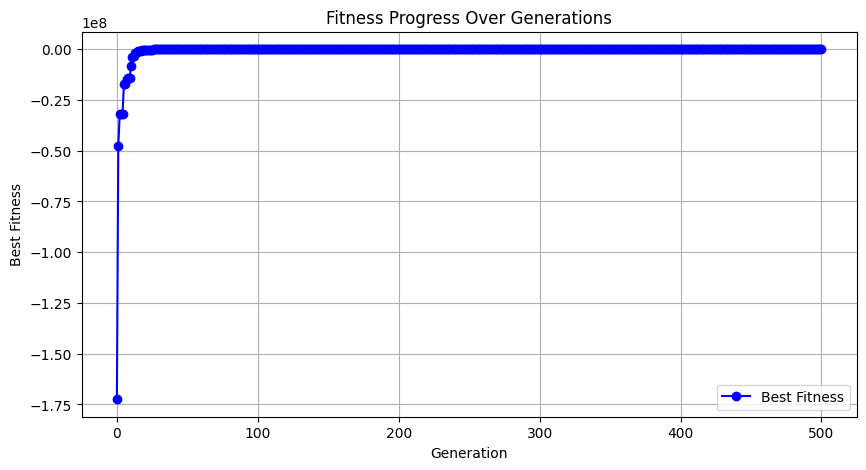

In [211]:
generations = list(range(len(fitness_history)))
plt.figure(figsize=(10, 5))
plt.plot(generations, fitness_history, marker='o', linestyle='-', color='b', label='Best Fitness')

plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("Fitness Progress Over Generations")
plt.legend()
plt.grid(True)
plt.show()